# ROCKET Benchmark — Interactive Exploration

Use this notebook to interactively explore benchmark results, tweak visualizations, and drill into specific datasets or classifiers.

**Prerequisite:** Run `benchmark.py` first to generate `results/benchmark_results.csv`.

In [1]:
import sys
import os

# Allow imports from src/
sys.path.insert(0, os.path.join(os.pardir, "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")

## 1. Load Results

In [2]:
from config import RESULTS_CSV

df = pd.read_csv(RESULTS_CSV)
print(f"Shape: {df.shape}")
df.head(10)

I0000 00:00:1773675037.016114   57945 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773675037.028897   57945 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773675038.797852   57945 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773675041.156057   57945 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_E

Shape: (175, 9)


,dataset,classifier,fold,accuracy,balanced_accuracy,f1_weighted,cohen_kappa,fit_time_s,predict_time_s
0,Computers,ROCKET,0,0.84,0.84,0.839422,0.68,14.940616,3.924044
1,Computers,1NN-ED,0,0.55,0.55,0.549595,0.10,0.002136,0.512998
2,Computers,1NN-DTW,0,0.70,0.70,0.698916,0.40,0.001124,97.296402
3,Computers,ST,0,0.78,0.78,0.778583,0.56,376.252124,8.162142
4,Computers,BOSS,0,0.84,0.84,0.839744,0.68,479.910183,3.084517
5,Computers,TSF,0,0.76,0.76,0.759133,0.52,7.611853,1.968031
6,Computers,catch22,0,0.71,0.71,0.709273,0.42,0.847106,0.109052
7,Computers,ROCKET,1,0.85,0.85,0.849985,0.70,14.588796,3.883935
8,Computers,1NN-ED,1,0.61,0.61,0.609023,0.22,0.000659,0.021052
9,Computers,1NN-DTW,1,0.72,0.72,0.719551,0.44,0.001758,97.467718


In [3]:
df.describe()

,fold,accuracy,balanced_accuracy,f1_weighted,cohen_kappa,fit_time_s,predict_time_s
count,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000,175.000000
mean,2.000000,0.769135,0.658682,0.750608,0.496678,69.488605,7.217053
std,1.418272,0.099655,0.160936,0.103876,0.276337,155.244867,19.889840
min,0.000000,0.442308,0.405556,0.447521,-0.124467,0.000335,0.001530
25%,1.000000,0.720000,0.505716,0.700536,0.373530,0.001405,0.106360
50%,2.000000,0.777778,0.610000,0.738957,0.593527,2.351494,0.697743
75%,3.000000,0.825000,0.820000,0.819712,0.680000,14.765349,2.842428
max,4.000000,0.975000,0.981481,0.975227,0.944134,837.767043,100.066874


## 2. Summary Statistics

In [4]:
# Mean accuracy: datasets x classifiers
mean_acc = df.groupby(["dataset", "classifier"])["accuracy"].mean().unstack()
std_acc = df.groupby(["dataset", "classifier"])["accuracy"].std().unstack()

mean_acc.round(4)

classifier,1NN-DTW,1NN-ED,BOSS,ROCKET,ST,TSF,catch22
dataset,,,,,,,
Computers,0.7100,0.5760,0.8360,0.8660,0.8100,0.7820,0.7860
DistalPhalanxTW,0.6884,0.7199,0.7551,0.7792,0.7588,0.7645,0.7607
ECG200,0.8250,0.8850,0.9050,0.9300,0.9050,0.9000,0.8150
Earthquakes,0.7332,0.7138,0.7917,0.7982,0.7917,0.7961,0.7831
Worms,0.6082,0.5118,0.7361,0.7167,0.7557,0.6744,0.7514


In [5]:
# Best classifier per dataset
print("Best classifier per dataset:")
mean_acc.idxmax(axis=1)

Best classifier per dataset:


dataset
Computers          ROCKET
DistalPhalanxTW    ROCKET
ECG200             ROCKET
Earthquakes        ROCKET
Worms                  ST
dtype: object

In [6]:
# Overall mean accuracy across all datasets
mean_acc.mean(axis=0).sort_values(ascending=False)

classifier
ROCKET     0.818013
BOSS       0.804799
ST         0.804243
TSF        0.783396
catch22    0.779238
1NN-DTW    0.712948
1NN-ED     0.681305
dtype: float64

## 3. Accuracy Exploration

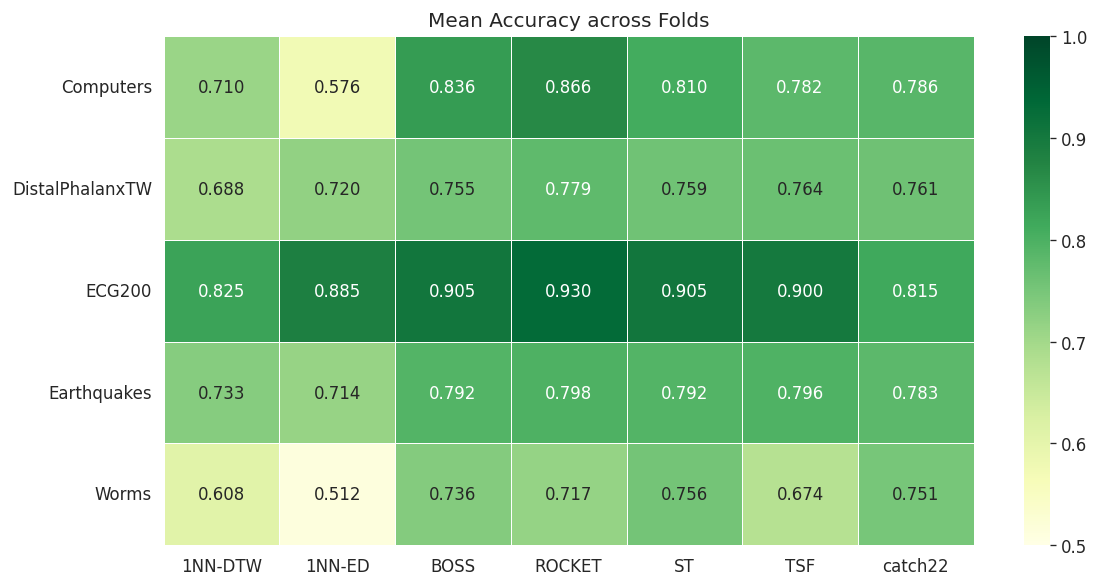

In [7]:
# Heatmap
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(mean_acc, annot=True, fmt=".3f", cmap="YlGn", ax=ax,
            linewidths=0.5, vmin=0.5, vmax=1.0)
ax.set_title("Mean Accuracy across Folds")
ax.set_ylabel("")
ax.set_xlabel("")
fig.tight_layout()
plt.show()

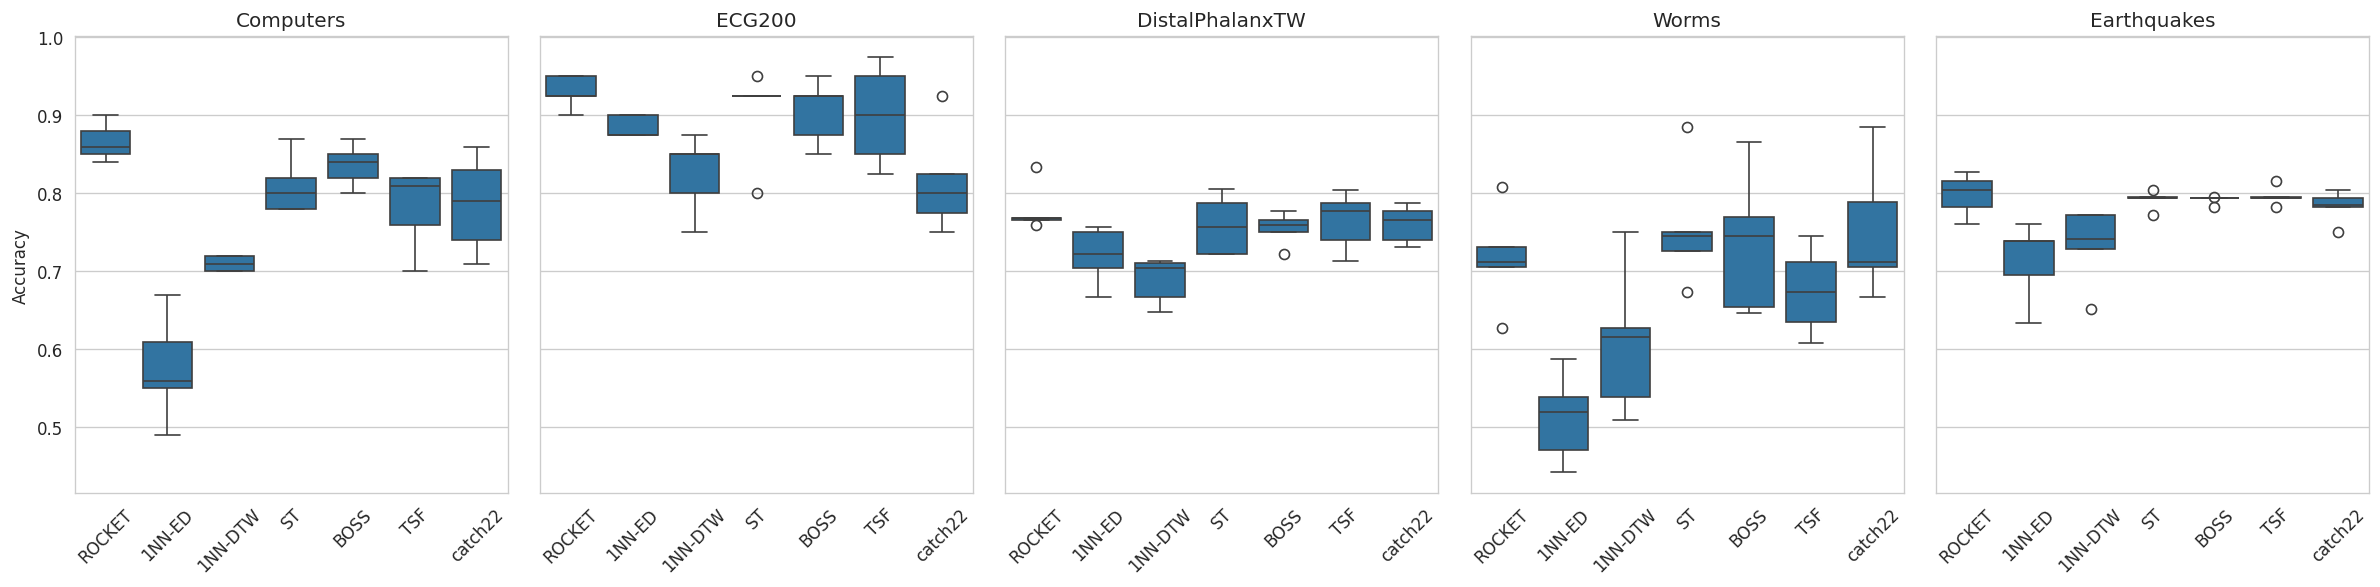

In [8]:
# Per-dataset boxplots
datasets = df["dataset"].unique()
n = len(datasets)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 5), sharey=True)
if n == 1:
    axes = [axes]
for ax, ds in zip(axes, datasets):
    sub = df[df["dataset"] == ds]
    sns.boxplot(data=sub, x="classifier", y="accuracy", ax=ax)
    ax.set_title(ds)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Accuracy")
fig.tight_layout()
plt.show()

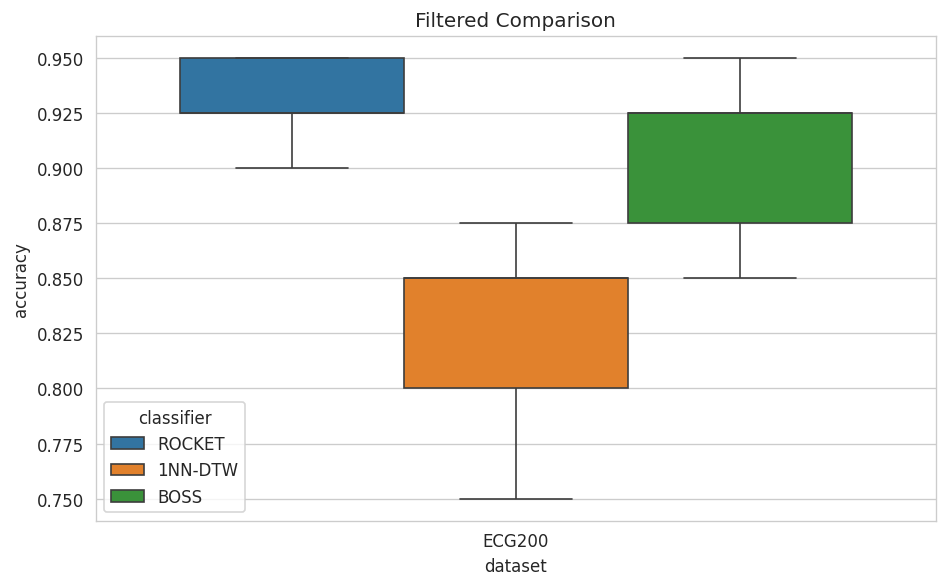

In [9]:
# --- Filter / compare specific classifiers or datasets ---
# Edit these lists to focus on a subset:
SELECTED_CLASSIFIERS = ["ROCKET", "1NN-DTW", "BOSS"]
SELECTED_DATASETS = ["GunPoint", "ECG200", "FaceAll"]

mask = df["classifier"].isin(SELECTED_CLASSIFIERS) & df["dataset"].isin(SELECTED_DATASETS)
sub = df[mask]

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=sub, x="dataset", y="accuracy", hue="classifier", ax=ax)
ax.set_title("Filtered Comparison")
fig.tight_layout()
plt.show()

## 4. Timing Analysis

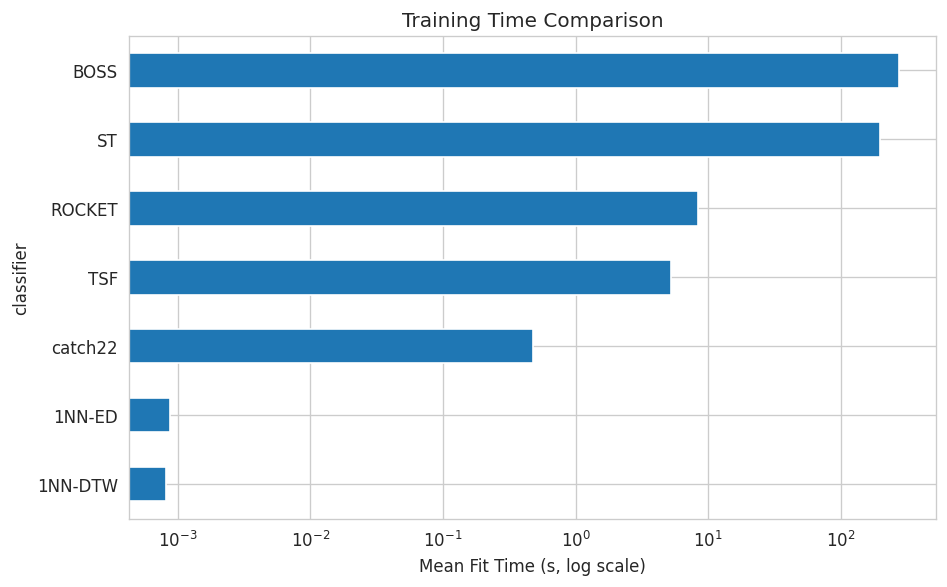

In [10]:
# Mean fit time per classifier
timing = df.groupby("classifier")["fit_time_s"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
timing.plot.barh(ax=ax)
ax.set_xscale("log")
ax.set_xlabel("Mean Fit Time (s, log scale)")
ax.set_title("Training Time Comparison")
fig.tight_layout()
plt.show()

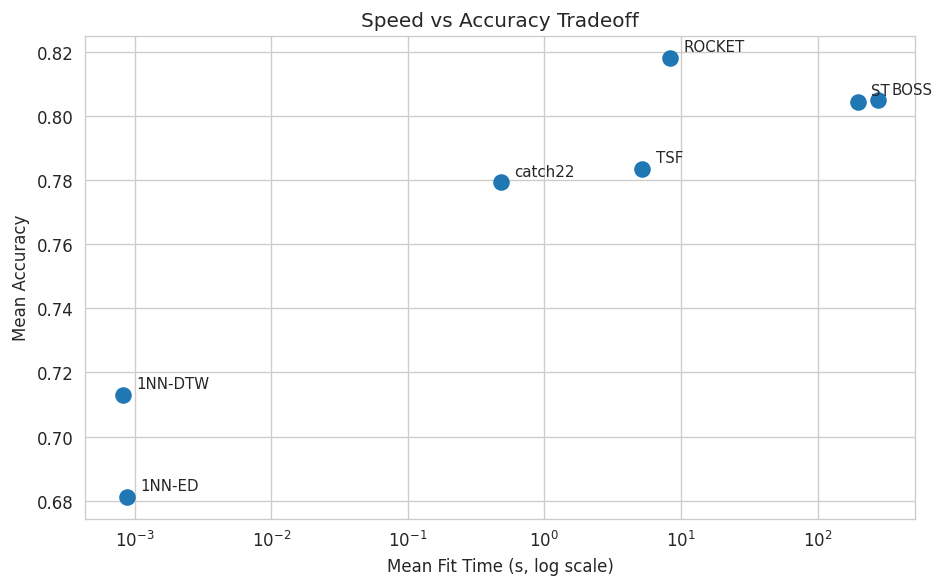

In [11]:
# Speed vs accuracy tradeoff
summary = df.groupby("classifier").agg(
    mean_accuracy=("accuracy", "mean"),
    mean_fit_time=("fit_time_s", "mean")
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(summary["mean_fit_time"], summary["mean_accuracy"], s=80)
for name, row in summary.iterrows():
    ax.annotate(name, (row["mean_fit_time"], row["mean_accuracy"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("Mean Fit Time (s, log scale)")
ax.set_ylabel("Mean Accuracy")
ax.set_title("Speed vs Accuracy Tradeoff")
fig.tight_layout()
plt.show()

## 5. Statistical Tests

In [12]:
from analysis import compute_ranks, friedman_test, nemenyi_cd

ranks, avg_ranks = compute_ranks(mean_acc)
fstat, fpval = friedman_test(mean_acc)

k = len(mean_acc.columns)
n_ds = len(mean_acc)
cd = nemenyi_cd(k, n_ds)

print(f"Friedman test: statistic = {fstat:.4f}, p-value = {fpval:.6f}")
print(f"Significant (p < 0.05): {fpval < 0.05}")
print(f"\nNemenyi CD = {cd:.4f}  (k={k}, N={n_ds})")
print(f"\nAverage ranks (lower is better):")
avg_ranks

Friedman test: statistic = 20.1151, p-value = 0.002642
Significant (p < 0.05): True

Nemenyi CD = 4.0291  (k=7, N=5)

Average ranks (lower is better):


classifier
ROCKET     1.6
ST         2.8
BOSS       3.2
TSF        3.6
catch22    4.2
1NN-DTW    6.2
1NN-ED     6.4
dtype: float64

In [ ]:
# CD Diagram (inline)
from analysis import plot_cd_diagram

# Temporarily override savefig to show inline instead
import matplotlib
_old_savefig = matplotlib.figure.Figure.savefig
matplotlib.figure.Figure.savefig = lambda self, *a, **kw: None

plot_cd_diagram(avg_ranks, cd)
plt.show()

matplotlib.figure.Figure.savefig = _old_savefig

Saved cd_diagram.pdf


## 6. Per-Dataset Deep Dive

Change `TARGET_DATASET` below to inspect a specific dataset.

In [15]:
TARGET_DATASET = "Worms"

sub = df[df["dataset"] == TARGET_DATASET]
print(f"Dataset: {TARGET_DATASET}")
print(f"Folds: {sub['fold'].nunique()}, Classifiers: {sub['classifier'].nunique()}")
sub.pivot_table(index="fold", columns="classifier", values="accuracy")

Dataset: Worms
Folds: 5, Classifiers: 7


classifier,1NN-DTW,1NN-ED,BOSS,ROCKET,ST,TSF,catch22
fold,,,,,,,
0,0.538462,0.442308,0.769231,0.711538,0.750000,0.673077,0.788462
1,0.615385,0.519231,0.653846,0.730769,0.673077,0.634615,0.711538
2,0.750000,0.538462,0.865385,0.807692,0.884615,0.711538,0.884615
3,0.627451,0.588235,0.745098,0.705882,0.745098,0.745098,0.705882
4,0.509804,0.470588,0.647059,0.627451,0.725490,0.607843,0.666667


In [16]:
# Fold-level variance per classifier
fold_var = sub.groupby("classifier")["accuracy"].std().sort_values(ascending=False)
print(f"Accuracy std across folds (higher = more variable):")
fold_var

Accuracy std across folds (higher = more variable):


classifier
1NN-DTW    0.093641
BOSS       0.090260
catch22    0.086545
ST         0.078268
ROCKET     0.064394
1NN-ED     0.057306
TSF        0.055659
Name: accuracy, dtype: float64

In [17]:
# Where does ROCKET win / lose vs each competitor?
pivot = sub.pivot_table(index="fold", columns="classifier", values="accuracy")
if "ROCKET" in pivot.columns:
    for clf in pivot.columns:
        if clf == "ROCKET":
            continue
        diff = pivot["ROCKET"] - pivot[clf]
        wins = (diff > 0).sum()
        losses = (diff < 0).sum()
        ties = (diff == 0).sum()
        print(f"ROCKET vs {clf:12s}: W={wins} L={losses} T={ties}  mean_diff={diff.mean():+.4f}")

ROCKET vs 1NN-DTW     : W=5 L=0 T=0  mean_diff=+0.1084
ROCKET vs 1NN-ED      : W=5 L=0 T=0  mean_diff=+0.2049
ROCKET vs BOSS        : W=1 L=4 T=0  mean_diff=-0.0195
ROCKET vs ST          : W=1 L=4 T=0  mean_diff=-0.0390
ROCKET vs TSF         : W=4 L=1 T=0  mean_diff=+0.0422
ROCKET vs catch22     : W=1 L=3 T=1  mean_diff=-0.0348
